# Eksperimen IHSG Lima *Seed*
## Apakah *Attention* Layak Dipertahankan?

Notebook ini membandingkan **CNN-BiGRU** dan **CNN-BiGRU-*Attention*** untuk
mengklasifikasikan arah penutupan IHSG pada hari perdagangan berikutnya.

\\[
y_{t+1}=1\\;\\text{jika}\\;Close_{t+1}>Close_t,\\quad 0\\;\\text{selainnya}
\\]

Keputusan desain memakai distribusi hasil lima *seed*, bukan skor tertinggi satu
percobaan. Aspek yang dinilai ialah akurasi, *balanced accuracy*, simpangan baku, F1, AUC, waktu
pelatihan, jumlah parameter, kestabilan prediksi, bobot *Attention*, dan
interpretabilitas.

**Perbaikan versi 3:** pemilihan arsitektur hanya memakai data validasi. Metrik
uji tidak dihitung sampai keputusan desain selesai. Implementasi *Attention*
juga memakai nama metode yang kompatibel dengan Keras 3 sehingga tidak menimpa
properti internal `Layer.weights`. Notebook juga membandingkan model dengan
*majority-class baseline*, membaca rasio simpangan baku secara benar, serta
menambahkan uji berpasangan dan interval *bootstrap* yang bersifat diagnostik.

**Petunjuk Kaggle:** unggah notebook ini ke [Kaggle Code](https://www.kaggle.com/code),
aktifkan **Internet**, pilih GPU bila tersedia, lalu tekan **Run All**. Hasil
tersimpan di `/kaggle/working/ihsg_attention_outputs`.

> Materi penelitian ini bukan rekomendasi investasi.

# Tahap 1. Algoritma Program

1. Tetapkan konfigurasi, lima *seed*, dan ambang keputusan.
2. Ambil OHLCV IHSG, urutkan tanggal, bersihkan duplikasi, lalu validasi kualitas.
3. Bentuk fitur teknikal hanya dari hari \\(t\\) dan masa lalu.
4. Bentuk target arah harga pada \\(t+1\\), lalu audit hubungan tanggal.
5. Bagi data kronologis menjadi latih 70%, validasi 15%, dan uji 15%.
6. Latih normalisasi hanya pada data latih.
7. Bentuk tensor \\([sampel, waktu, fitur]\\) dengan jendela 30 hari.
8. Latih dua model pada lima *seed* memakai kontrol yang sama.
9. Hitung *majority-class baseline*, metrik validasi, stabilitas, biaya komputasi, dan bobot *Attention*.
10. Pilih arsitektur memakai aturan yang ditetapkan sebelum hasil terlihat.
11. Hitung metrik uji hanya untuk mengonfirmasi model yang sudah dipilih.
12. Susun memo integritas, register bug, serta ekspor seluruh hasil.

*Attention* dipertahankan hanya jika kenaikan rata-rata akurasi dan *balanced
accuracy* masing-masing minimal 0,5 poin persentase, menang sekurangnya empat
*seed*, rasio simpangan baku tidak melebihi 1,15, rasio waktu tidak melebihi
1,50, dan skor interpretabilitas tidak menurun. Kelayakan model terhadap tebakan
kelas mayoritas dilaporkan terpisah dari keputusan memilih arsitektur.

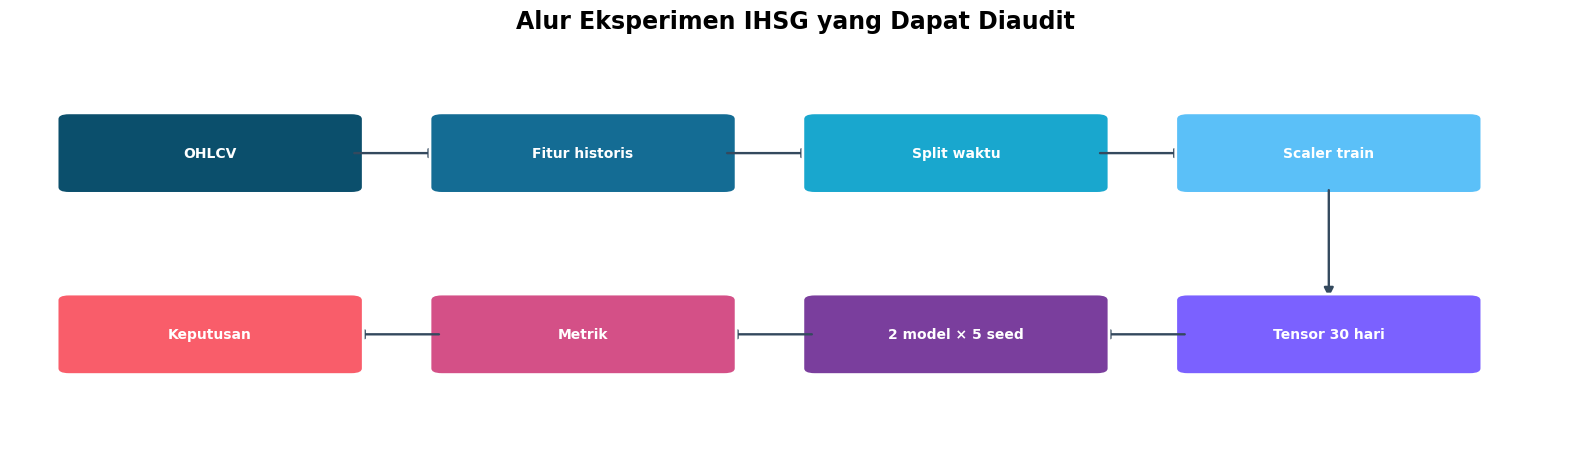

In [1]:
# Output Tahap 1: diagram alur algoritma
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

labels = ["OHLCV", "Fitur historis", "Split waktu", "Scaler train",
          "Tensor 30 hari", "2 model × 5 seed", "Metrik", "Keputusan"]
colors = ["#0B4F6C","#146C94","#19A7CE","#5BC0F8",
          "#7B61FF","#7A3E9D","#D45087","#F95D6A"]
pos = [(0.15,1.25),(1.10,1.25),(2.05,1.25),(3.00,1.25),
       (3.00,.35),(2.05,.35),(1.10,.35),(.15,.35)]
fig, ax = plt.subplots(figsize=(16,4.6))
ax.set(xlim=(0,4), ylim=(0,2)); ax.axis("off")
for i, ((x,y), lab, col) in enumerate(zip(pos,labels,colors)):
    ax.add_patch(FancyBboxPatch((x,y),.72,.34,boxstyle="round,pad=.03",
                 facecolor=col,edgecolor="white",linewidth=2))
    ax.text(x+.36,y+.17,lab,ha="center",va="center",color="white",
            fontsize=10,fontweight="bold")
    if i < 7:
        x2,y2=pos[i+1]
        if i<3: a,b=(x+.72,y+.17),(x2,y2+.17)
        elif i==3: a,b=(x+.36,y),(x2+.36,y2+.34)
        else: a,b=(x,y+.17),(x2+.72,y2+.17)
        ax.add_patch(FancyArrowPatch(a,b,arrowstyle="-|>",mutation_scale=14,
                     color="#34495E",linewidth=1.7))
ax.set_title("Alur Eksperimen IHSG yang Dapat Diaudit",fontsize=17,fontweight="bold")
plt.tight_layout(); plt.show()

# Tahap 2. *Pseudocode*

```text
MULAI
  SEEDS <- [11, 23, 37, 53, 71]
  ambil dan urutkan OHLCV IHSG
  hitung fitur dari informasi sampai hari t
  buat target arah harga pada t+1
  audit tanggal target, split, scaler, dan tensor
  split kronologis 70:15:15
  fit scaler hanya pada train
  buat sequence 30 hari
  UNTUK setiap seed:
    latih CNN-BiGRU dan CNN-BiGRU-Attention pada kontrol sama
    simpan metrik validasi, waktu, parameter, dan bobot model
    simpan bobot Attention dari validasi
  hitung majority-class baseline dari label train
  hitung mean, SD, balanced accuracy, selisih berpasangan, dan stabilitas pada validasi
  terapkan seluruh aturan keputusan
  hitung hasil test hanya untuk model yang sudah dipilih
  tetapkan status VALID, MERAGUKAN, atau TIDAK SAH
  tampilkan tabel, grafik, memo, dan ekspor
SELESAI
```

In [2]:
# Output Tahap 2: kontrol logika pseudocode
import pandas as pd
display(pd.DataFrame({
 "Kontrol":["Urutan waktu","Target t+1","Scaler train-only","Tensor 3D",
            "Kontrol identik","Lima seed","Keputusan multi-kriteria"],
 "Risiko dicegah":["Masa depan masuk masa lalu","Target bocor ke fitur",
                   "Statistik test bocor","Input GRU salah","Ablasi tidak adil",
                   "Keberuntungan acak","Memilih skor tunggal"],
 "Status":["DIWAJIBKAN"]*7
}))

,Kontrol,Risiko dicegah,Status
0,Urutan waktu,Masa depan masuk masa lalu,DIWAJIBKAN
1,Target t+1,Target bocor ke fitur,DIWAJIBKAN
2,Scaler train-only,Statistik test bocor,DIWAJIBKAN
3,Tensor 3D,Input GRU salah,DIWAJIBKAN
4,Kontrol identik,Ablasi tidak adil,DIWAJIBKAN
5,Lima seed,Keberuntungan acak,DIWAJIBKAN
6,Keputusan multi-kriteria,Memilih skor tunggal,DIWAJIBKAN


# Tahap 3. Persiapan Lingkungan
Paket, konfigurasi, dan perangkat diperiksa sebelum data diproses.

In [3]:
!pip -q install yfinance

In [4]:
import os, gc, json, random, time, warnings, platform, shutil
from pathlib import Path
from datetime import date, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import tensorflow as tf
from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
                             f1_score,roc_auc_score,balanced_accuracy_score,confusion_matrix,
                             classification_report)
from scipy.stats import spearmanr, wilcoxon, binomtest

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid",context="notebook")
pd.set_option("display.max_columns",100)

CFG={"ticker":"^JKSE","start":"2010-01-01",
 "end":(date.today()+timedelta(days=1)).isoformat(),
 "window":30,"train_ratio":.70,"val_ratio":.15,
 "batch_size":64,"epochs":25,"patience":5,"lr":1e-3,
 "seeds":[11,23,37,53,71],"min_gain":.005,"min_wins":4,
 "max_sd_ratio":1.15,"max_time_ratio":1.50,"threshold":.50,
 "bootstrap_repeats":10000}
OUT=Path("/kaggle/working/ihsg_attention_outputs"); OUT.mkdir(parents=True,exist_ok=True)
try: tf.config.experimental.enable_op_determinism()
except Exception: pass

display(pd.DataFrame({
 "Komponen":["Python","TensorFlow","NumPy","Pandas","Perangkat","Seed"],
 "Nilai":[platform.python_version(),tf.__version__,np.__version__,pd.__version__,
          tf.config.list_physical_devices("GPU") or "CPU",str(CFG["seeds"])]
}))

,Komponen,Nilai
0,Python,3.12.13
1,TensorFlow,2.20.0
2,NumPy,2.0.2
3,Pandas,2.3.3
4,Perangkat,"[(/physical_device:GPU:0, GPU), (/physical_dev..."
5,Seed,"[11, 23, 37, 53, 71]"


# Tahap 4. Akuisisi dan Validasi Data

Sumber utama ialah Yahoo Finance (`^JKSE`). Jika Internet gagal, program mencari
CSV OHLCV pada `/kaggle/input`. Jalur cadangan mencegah kegagalan tunggal dari
jaringan, tetapi tidak mengubah aturan validasi.

,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,2533.947998,2576.055908,2532.895996,2575.413086,18339300
2010-01-05,2575.616943,2606.069092,2575.616943,2605.277100,57043800
2010-01-06,2605.480957,2622.115967,2587.709961,2603.297119,51569100
2010-01-07,2603.500977,2611.603027,2570.272949,2586.895020,45510800
2010-01-08,2586.792969,2614.535889,2583.846924,2614.370117,73723500


,Pemeriksaan,Hasil
0,Sumber,Yahoo Finance (^JKSE)
1,Awal,2010-01-04
2,Akhir,2026-07-30
3,Baris,4019
4,Duplikasi,0
5,Kosong,0
6,High < Low,0
7,Volume negatif,0


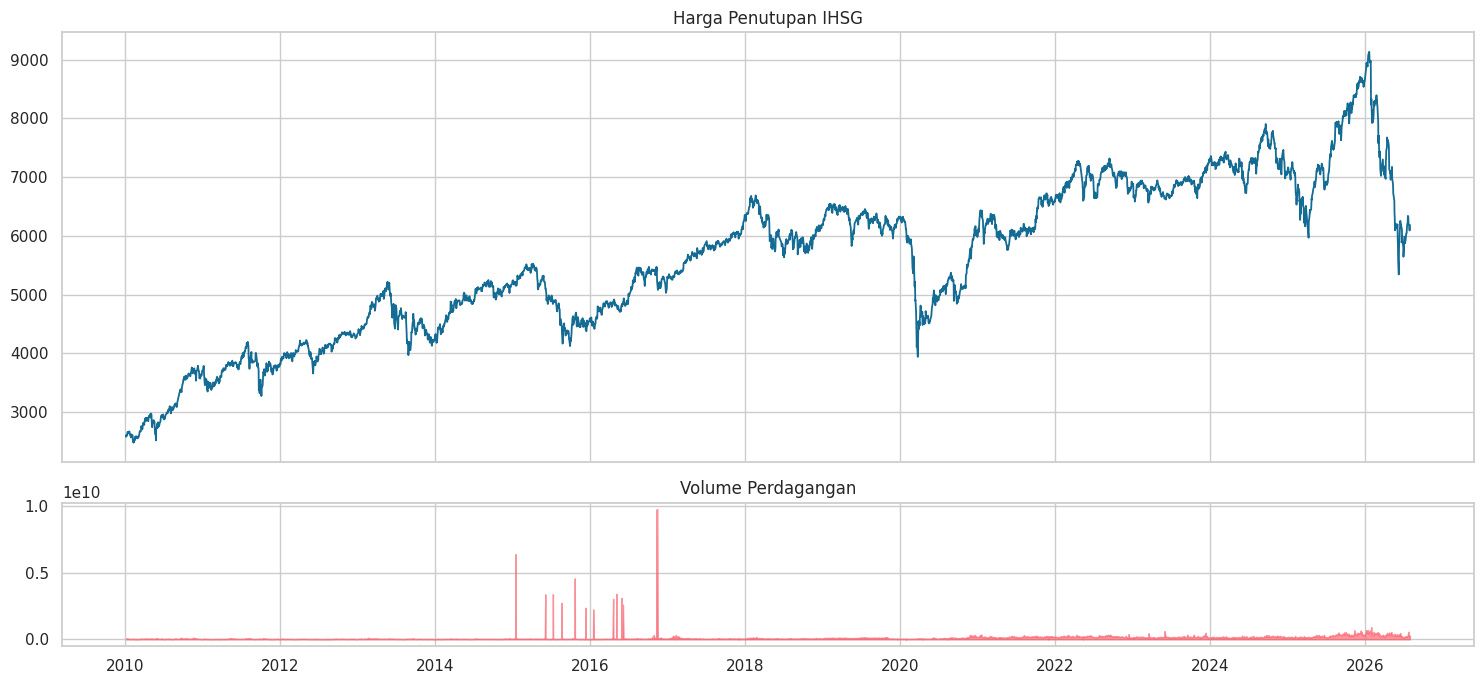

In [5]:
def flatten_cols(df):
    x=df.copy()
    if isinstance(x.columns,pd.MultiIndex): x.columns=[c[0] for c in x.columns]
    return x

def standardize(df):
    x=df.copy()
    x.columns=[str(c).strip().title().replace("_"," ") for c in x.columns]
    x=x.rename(columns={"Tanggal":"Date","Datetime":"Date","Timestamp":"Date"})
    if "Date" in x.columns:
        x["Date"]=pd.to_datetime(x["Date"],errors="coerce"); x=x.set_index("Date")
    x.index=pd.to_datetime(x.index,errors="coerce"); x.index.name="Date"
    req=["Open","High","Low","Close","Volume"]
    miss=[c for c in req if c not in x.columns]
    if miss: raise ValueError(f"Kolom wajib hilang: {miss}")
    x=x[req].apply(pd.to_numeric,errors="coerce")
    x=x[~x.index.isna()].sort_index()
    x=x[~x.index.duplicated(keep="last")]
    return x.dropna(subset=req)

def load_data():
    try:
        x=yf.download(CFG["ticker"],start=CFG["start"],end=CFG["end"],
                      auto_adjust=False,progress=False,threads=False)
        x=standardize(flatten_cols(x))
        if len(x)<500: raise ValueError("Data daring terlalu sedikit")
        return x,"Yahoo Finance (^JKSE)"
    except Exception as online_error:
        for p in sorted(Path("/kaggle/input").rglob("*.csv")):
            try:
                x=standardize(pd.read_csv(p))
                if len(x)>=500: return x,f"CSV Kaggle: {p}"
            except Exception: continue
        raise RuntimeError("Aktifkan Internet atau unggah CSV OHLCV IHSG.") from online_error

raw,source=load_data()
quality=pd.DataFrame({
 "Pemeriksaan":["Sumber","Awal","Akhir","Baris","Duplikasi","Kosong","High < Low","Volume negatif"],
 "Hasil":[source,raw.index.min().date(),raw.index.max().date(),len(raw),
          raw.index.duplicated().sum(),raw.isna().sum().sum(),
          (raw.High<raw.Low).sum(),(raw.Volume<0).sum()]})
display(raw.head()); display(quality)

fig,ax=plt.subplots(2,1,figsize=(15,7),sharex=True,gridspec_kw={"height_ratios":[3,1]})
ax[0].plot(raw.index,raw.Close,color="#146C94",lw=1.3); ax[0].set_title("Harga Penutupan IHSG")
ax[1].fill_between(raw.index,raw.Volume.to_numpy(),color="#F95D6A",alpha=.65)
ax[1].set_title("Volume Perdagangan"); plt.tight_layout(); plt.show()

# Tahap 5. Fitur dan Target

Fitur memakai informasi pada hari \\(t\\) atau sebelumnya. Satu-satunya
pergeseran ke depan dipakai untuk target dan tanggal target.

,InputEndDate,TargetDate,Close,Target,TargetAfterInput
Date,,,,,
2026-07-20,2026-07-20,2026-07-21,6231.779785,1,True
2026-07-21,2026-07-21,2026-07-22,6340.020020,0,True
2026-07-22,2026-07-22,2026-07-23,6334.476074,0,True
2026-07-23,2026-07-23,2026-07-24,6315.311035,0,True
2026-07-24,2026-07-24,2026-07-27,6196.430176,0,True
2026-07-27,2026-07-27,2026-07-28,6185.783203,0,True
2026-07-28,2026-07-28,2026-07-29,6130.587891,0,True
2026-07-29,2026-07-29,2026-07-30,6091.386230,1,True


,mean,std,min,max
Open,5.591334e+03,1.322391e+03,2474.7500,9.156190e+03
High,5.621198e+03,1.326390e+03,2490.1089,9.174474e+03
Low,5.555582e+03,1.314341e+03,2431.8379,9.120154e+03
Close,5.589184e+03,1.319022e+03,2475.5720,9.134700e+03
Volume,1.229334e+08,2.988797e+08,0.0000,9.788202e+09
Return1,3.000000e-04,1.090000e-02,-0.0888,1.019000e-01
LogReturn,2.000000e-04,1.090000e-02,-0.0930,9.700000e-02
RangePct,1.200000e-02,8.300000e-03,0.0000,1.002000e-01
OCChange,-2.000000e-04,9.700000e-03,-0.0884,1.019000e-01
SMA5Ratio,5.000000e-04,1.210000e-02,-0.0873,8.190000e-02


,Jumlah,Proporsi
Target,,
Turun/Tetap,1828,45.80%
Naik,2163,54.20%


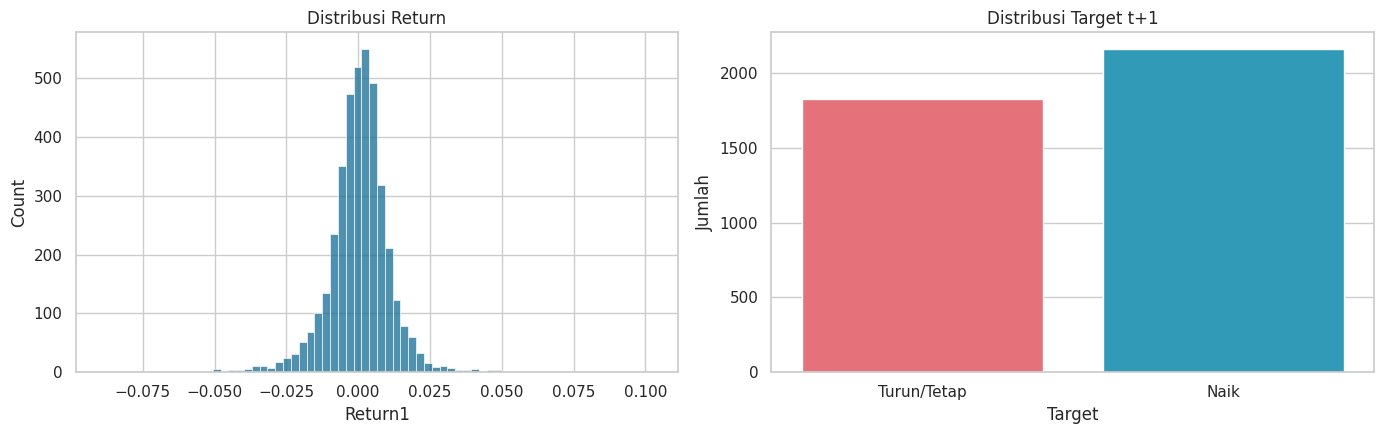

In [6]:
def rsi(s,n=14):
    d=s.diff(); g=d.clip(lower=0).ewm(alpha=1/n,adjust=False).mean()
    l=(-d.clip(upper=0)).ewm(alpha=1/n,adjust=False).mean()
    return 100-100/(1+g/l.replace(0,np.nan))

def feature_engineering(x):
    d=x.copy()
    d["Return1"]=d.Close.pct_change(); d["LogReturn"]=np.log(d.Close).diff()
    d["RangePct"]=(d.High-d.Low)/d.Close; d["OCChange"]=(d.Close-d.Open)/d.Open
    d["SMA5Ratio"]=d.Close/d.Close.rolling(5).mean()-1
    d["SMA20Ratio"]=d.Close/d.Close.rolling(20).mean()-1
    e12=d.Close.ewm(span=12,adjust=False).mean(); e26=d.Close.ewm(span=26,adjust=False).mean()
    d["MACD"]=(e12-e26)/d.Close; d["RSI14"]=rsi(d.Close)/100
    d["Volatility10"]=d.LogReturn.rolling(10).std()
    d["VolumeChange"]=d.Volume.pct_change().replace([np.inf,-np.inf],np.nan)
    d["VolumeZ20"]=(d.Volume-d.Volume.rolling(20).mean())/d.Volume.rolling(20).std().replace(0,np.nan)
    nxt=d.Close.shift(-1); d["Target"]=np.where(nxt.notna(),(nxt>d.Close).astype(int),np.nan)
    d["TargetDate"]=pd.Series(d.index,index=d.index).shift(-1)
    return d

FEATURES=["Open","High","Low","Close","Volume","Return1","LogReturn","RangePct",
          "OCChange","SMA5Ratio","SMA20Ratio","MACD","RSI14","Volatility10",
          "VolumeChange","VolumeZ20"]
data=feature_engineering(raw).replace([np.inf,-np.inf],np.nan)
data=data.dropna(subset=FEATURES+["Target","TargetDate"]).copy()
data["Target"]=data.Target.astype(int)
align=data[["Close","Target","TargetDate"]].tail(8).copy()
align["InputEndDate"]=align.index; align["TargetAfterInput"]=align.TargetDate>align.InputEndDate
display(align[["InputEndDate","TargetDate","Close","Target","TargetAfterInput"]])
display(data[FEATURES].describe().T[["mean","std","min","max"]].round(4))
classes=data.Target.value_counts().sort_index().rename(index={0:"Turun/Tetap",1:"Naik"}).to_frame("Jumlah")
classes["Proporsi"]=classes.Jumlah/classes.Jumlah.sum()
display(classes.style.format({"Proporsi":"{:.2%}"}))
fig,ax=plt.subplots(1,2,figsize=(14,4.5))
sns.histplot(data=data,x="Return1",bins=70,color="#146C94",ax=ax[0]); ax[0].set_title("Distribusi Return")
sns.barplot(x=classes.index,y=classes.Jumlah,palette=["#F95D6A","#19A7CE"],ax=ax[1])
ax[1].set_title("Distribusi Target t+1"); plt.tight_layout(); plt.show()

# Tahap 6. Split, Normalisasi, dan Tensor
Split mengikuti waktu. Scaler hanya di-*fit* pada baris latih.

,Split,Sampel,Awal target,Akhir target,Proporsi naik
0,Train,2764,2010-03-12 00:00:00,2021-07-27 00:00:00,54.67%
1,Validasi,599,2021-07-28 00:00:00,2024-01-10 00:00:00,54.26%
2,Test,599,2024-01-11 00:00:00,2026-07-29 00:00:00,52.09%


,Tensor,Shape,Finite
0,X_train,"(2764, 30, 16)",True
1,X_val,"(599, 30, 16)",True
2,X_test,"(599, 30, 16)",True
3,y_train,"(2764,)",True
4,y_val,"(599,)",True
5,y_test,"(599,)",True


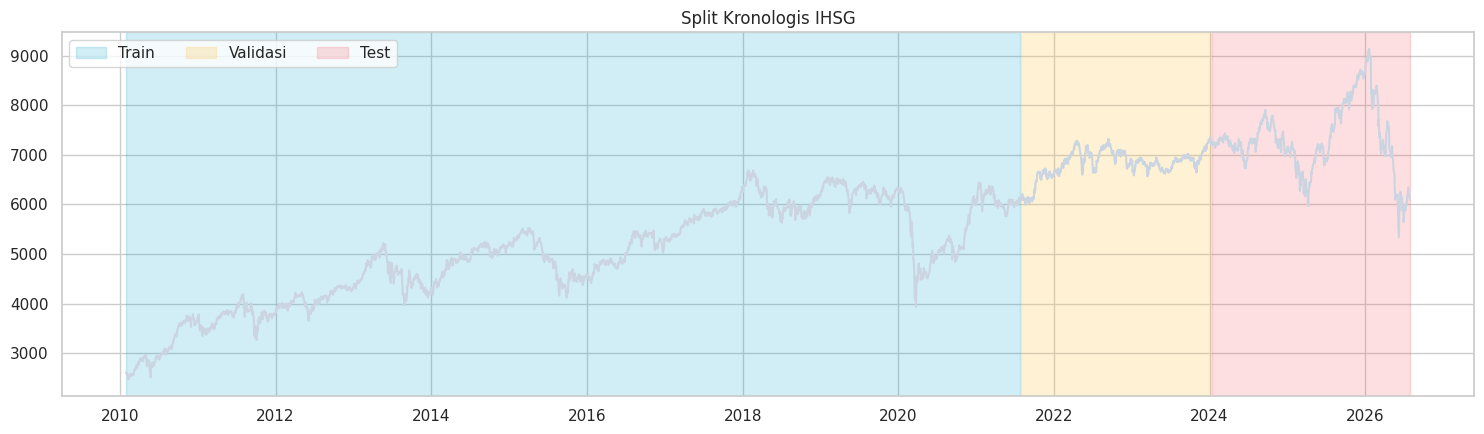

In [7]:
n=len(data); tr=int(n*CFG["train_ratio"]); va=int(n*(CFG["train_ratio"]+CFG["val_ratio"]))
scaler=StandardScaler().fit(data.iloc[:tr][FEATURES])
Xall=scaler.transform(data[FEATURES]).astype("float32"); yall=data.Target.to_numpy("float32")

def sequences(X,y,idx,w,tr,va):
    B={k:{"X":[],"y":[],"d":[]} for k in ["train","val","test"]}
    for e in range(w-1,len(X)):
        k="train" if e<tr else ("val" if e<va else "test")
        B[k]["X"].append(X[e-w+1:e+1]); B[k]["y"].append(y[e]); B[k]["d"].append(idx[e])
    return {k:(np.asarray(v["X"],dtype="float32"),np.asarray(v["y"],dtype="float32"),
               pd.DatetimeIndex(v["d"])) for k,v in B.items()}

S=sequences(Xall,yall,data.index,CFG["window"],tr,va)
X_train,y_train,d_train=S["train"]; X_val,y_val,d_val=S["val"]; X_test,y_test,d_test=S["test"]
split=pd.DataFrame([
 ["Train",len(X_train),d_train.min(),d_train.max(),y_train.mean()],
 ["Validasi",len(X_val),d_val.min(),d_val.max(),y_val.mean()],
 ["Test",len(X_test),d_test.min(),d_test.max(),y_test.mean()]],
 columns=["Split","Sampel","Awal target","Akhir target","Proporsi naik"])
tensor=pd.DataFrame({"Tensor":["X_train","X_val","X_test","y_train","y_val","y_test"],
 "Shape":[str(z.shape) for z in [X_train,X_val,X_test,y_train,y_val,y_test]],
 "Finite":[np.isfinite(z).all() for z in [X_train,X_val,X_test,y_train,y_val,y_test]]})
display(split.style.format({"Proporsi naik":"{:.2%}"})); display(tensor)
fig,ax=plt.subplots(figsize=(15,4.5)); ax.plot(data.index,data.Close,color="#CBD5E1")
ax.axvspan(data.index[0],data.index[tr-1],color="#19A7CE",alpha=.2,label="Train")
ax.axvspan(data.index[tr],data.index[va-1],color="#FFC857",alpha=.25,label="Validasi")
ax.axvspan(data.index[va],data.index[-1],color="#F95D6A",alpha=.2,label="Test")
ax.set_title("Split Kronologis IHSG"); ax.legend(ncol=3); plt.tight_layout(); plt.show()

# Tahap 7. Audit Kebocoran

Audit kritis menghentikan eksperimen jika gagal. BiGRU tidak otomatis bocor:
arah mundur hanya membaca ulang isi jendela historis yang berakhir pada hari \\(t\\).

In [8]:
audit=[]
def check(name,ok,evidence,level="KRITIS"):
    audit.append({"Pemeriksaan":name,"Lulus":bool(ok),"Bukti":str(evidence),"Tingkat":level})
check("Index meningkat",data.index.is_monotonic_increasing,data.index.is_monotonic_increasing)
check("Tanggal unik",data.index.is_unique,f"duplikat={data.index.duplicated().sum()}")
check("Target setelah input",(data.TargetDate>data.index).all(),"semua target > input")
check("Split tidak tumpang tindih",d_train.max()<d_val.min()<d_test.min(),
      f"{d_train.max().date()} < {d_val.min().date()} < {d_test.min().date()}")
check("Scaler train-only",scaler.n_samples_seen_==tr,f"{scaler.n_samples_seen_} = {tr}")
check("Tensor 3D",X_train.ndim==X_val.ndim==X_test.ndim==3,
      f"{X_train.shape}, {X_val.shape}, {X_test.shape}")
check("Window benar",X_train.shape[1]==CFG["window"],X_train.shape[1])
check("Fitur benar",X_train.shape[2]==len(FEATURES),X_train.shape[2])
check("Nilai finite",all(np.isfinite(z).all() for z in [X_train,X_val,X_test]),"tanpa NaN/Inf")
check("Validasi dua kelas",len(np.unique(y_val))==2,np.unique(y_val).tolist(),"TINGGI")
check("Test dua kelas",len(np.unique(y_test))==2,np.unique(y_test).tolist(),"TINGGI")
audit_df=pd.DataFrame(audit)
display(audit_df.style.apply(lambda r:["background-color:#DCFCE7" if r.Lulus else
 "#FEE2E2"]*len(r),axis=1))
if len(audit_df.query("Tingkat=='KRITIS' and Lulus==False")):
    raise RuntimeError("AUDIT GAGAL. Eksperimen dihentikan.")

,Pemeriksaan,Lulus,Bukti,Tingkat
0,Index meningkat,True,True,KRITIS
1,Tanggal unik,True,duplikat=0,KRITIS
2,Target setelah input,True,semua target > input,KRITIS
3,Split tidak tumpang tindih,True,2021-07-27 < 2021-07-28 < 2024-01-11,KRITIS
4,Scaler train-only,True,2793 = 2793,KRITIS
5,Tensor 3D,True,"(2764, 30, 16), (599, 30, 16), (599, 30, 16)",KRITIS
6,Window benar,True,30,KRITIS
7,Fitur benar,True,16,KRITIS
8,Nilai finite,True,tanpa NaN/Inf,KRITIS
9,Validasi dua kelas,True,"[0.0, 1.0]",TINGGI


# Tahap 8. Arsitektur

Kedua model memakai CNN dan BiGRU identik. Pembanding memakai rata-rata global,
sedangkan model perlakuan memakai *additive temporal attention*.

In [9]:
@tf.keras.utils.register_keras_serializable(package="IHSG")
class TemporalAttention(tf.keras.layers.Layer):
    # Additive temporal attention yang kompatibel dengan Keras 3.
    # `weights` tidak dipakai sebagai nama metode karena merupakan properti Layer.
    def __init__(self,units=32,**kw):
        super().__init__(**kw); self.units=units
        self.energy=tf.keras.layers.Dense(units,activation="tanh",name="energy")
        self.projection=tf.keras.layers.Dense(1,use_bias=False,name="projection")
    def compute_attention_weights(self,inputs):
        logits=self.projection(self.energy(inputs))
        return tf.nn.softmax(logits,axis=1)
    def call(self,inputs):
        alpha=self.compute_attention_weights(inputs)
        return tf.reduce_sum(inputs*alpha,axis=1)
    def get_config(self): return {**super().get_config(),"units":self.units}

def set_seed(seed):
    os.environ["PYTHONHASHSEED"]=str(seed); random.seed(seed); np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

def build_model(shape,attention,seed):
    tf.keras.backend.clear_session(); set_seed(seed)
    i=tf.keras.Input(shape=shape,name="window")
    x=tf.keras.layers.Conv1D(32,2,padding="causal",activation="relu",name="cnn")(i)
    x=tf.keras.layers.BatchNormalization(name="bn")(x)
    x=tf.keras.layers.Dropout(.2,seed=seed)(x)
    x=tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32,return_sequences=True,
           dropout=.1),name="bigru")(x)
    x=tf.keras.layers.Dropout(.2,seed=seed+1)(x)
    if attention:
        x=TemporalAttention(32,name="attention")(x); name="CNN-BiGRU-Attention"
    else:
        x=tf.keras.layers.GlobalAveragePooling1D(name="average")(x); name="CNN-BiGRU"
    x=tf.keras.layers.Dense(32,activation="relu")(x)
    x=tf.keras.layers.Dropout(.15,seed=seed+2)(x)
    o=tf.keras.layers.Dense(1,activation="sigmoid")(x)
    m=tf.keras.Model(i,o,name=name)
    m.compile(tf.keras.optimizers.Adam(CFG["lr"]),"binary_crossentropy",
              metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy"),
                       tf.keras.metrics.AUC(name="auc")])
    return m

b=build_model(X_train.shape[1:],False,CFG["seeds"][0])
a=build_model(X_train.shape[1:],True,CFG["seeds"][0])
att_layer=a.get_layer("attention")
encoder=tf.keras.Model(a.input,a.get_layer("bigru").output)
probe=encoder(X_train[:2],training=False)
probe_alpha=att_layer.compute_attention_weights(probe).numpy()
assert isinstance(att_layer.weights,list), "Properti Layer.weights tertimpa."
assert np.allclose(probe_alpha.sum(axis=1),1.0,atol=1e-6), "Bobot Attention tidak berjumlah satu."
display(pd.DataFrame({
 "Model":["CNN-BiGRU","CNN-BiGRU-Attention"],
 "Agregasi":["Rata-rata global","Bobot Attention"],
 "Parameter":[b.count_params(),a.count_params()],
 "Input":[str(X_train.shape[1:])]*2,"Output":[str(b.output_shape),str(a.output_shape)],
 "Keras_Weights_OK":[True,isinstance(att_layer.weights,list)]}))
display(pd.DataFrame({"Pemeriksaan":["Shape bobot Attention","Jumlah bobot per sampel"],
 "Hasil":[str(probe_alpha.shape),np.round(probe_alpha.sum(axis=1),6).tolist()],
 "Status":["LULUS","LULUS"]}))

I0000 00:00:1785534403.582534      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785534403.585842      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


,Model,Agregasi,Parameter,Input,Output,Keras_Weights_OK
0,CNN-BiGRU,Rata-rata global,15969,"(30, 16)","(None, 1)",True
1,CNN-BiGRU-Attention,Bobot Attention,18081,"(30, 16)","(None, 1)",True


,Pemeriksaan,Hasil,Status
0,Shape bobot Attention,"(2, 30, 1)",LULUS
1,Jumlah bobot per sampel,"[[1.0], [1.0]]",LULUS


# Tahap 9. Pelatihan Lima *Seed*

Pelatihan dilakukan berpasangan. Urutan model diselang-seling untuk mengurangi
bias beban perangkat. *Early stopping* mengembalikan bobot validasi terbaik.

,Model,Aturan,Train_Prevalence_Up,Val_Accuracy,Val_Balanced_Accuracy,Val_Precision,Val_Recall,Val_F1,Val_ROC_AUC
0,Majority-class baseline,Selalu prediksi kelas 1 berdasarkan train,0.5467,0.5426,0.5000,0.5426,1.0000,0.7035,0.5000


2026-07-31 21:46:48.772648: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-31 21:46:55.677893: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

CNN-BiGRU                | seed=11 | val_acc=0.4574 | 11.0s


2026-07-31 21:47:01.155312: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-31 21:47:09.941993: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

CNN-BiGRU-Attention      | seed=11 | val_acc=0.5426 | 8.8s


...

2026-07-31 21:48:15.775898: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-31 21:48:23.789381: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

CNN-BiGRU                | seed=71 | val_acc=0.4574 | 8.0s


2026-07-31 21:48:29.856755: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-31 21:48:34.918959: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

CNN-BiGRU-Attention      | seed=71 | val_acc=0.4574 | 8.8s


,Model,Seed,Train_Time_s,Parameters,Epochs_Run,Best_Val_Loss,Val_Accuracy,Val_Balanced_Accuracy,Val_Precision,Val_Recall,Val_F1,Val_ROC_AUC
0,CNN-BiGRU,11,11.0,15969,6,0.6980,0.4574,0.4983,0.5000,0.0185,0.0356,0.5131
1,CNN-BiGRU-Attention,11,8.8,18081,6,0.6936,0.5426,0.5000,0.5426,1.0000,0.7035,0.4951
2,CNN-BiGRU,23,8.1,15969,6,0.6934,0.5426,0.5000,0.5426,1.0000,0.7035,0.4779
3,CNN-BiGRU-Attention,23,8.8,18081,6,0.6942,0.4758,0.4748,0.5180,0.4862,0.5016,0.4935
4,CNN-BiGRU,37,9.6,15969,8,0.6916,0.5442,0.5058,0.5456,0.9569,0.6950,0.4862
5,CNN-BiGRU-Attention,37,8.8,18081,6,0.6954,0.4541,0.4660,0.4953,0.3262,0.3933,0.4842
6,CNN-BiGRU,53,8.2,15969,6,0.7290,0.4574,0.5000,0.0000,0.0000,0.0000,0.5280
7,CNN-BiGRU-Attention,53,8.8,18081,6,0.7306,0.4574,0.5000,0.0000,0.0000,0.0000,0.5166
8,CNN-BiGRU,71,8.0,15969,6,0.7131,0.4574,0.5000,0.0000,0.0000,0.0000,0.5136
9,CNN-BiGRU-Attention,71,8.8,18081,6,0.7200,0.4574,0.5000,0.0000,0.0000,0.0000,0.5158


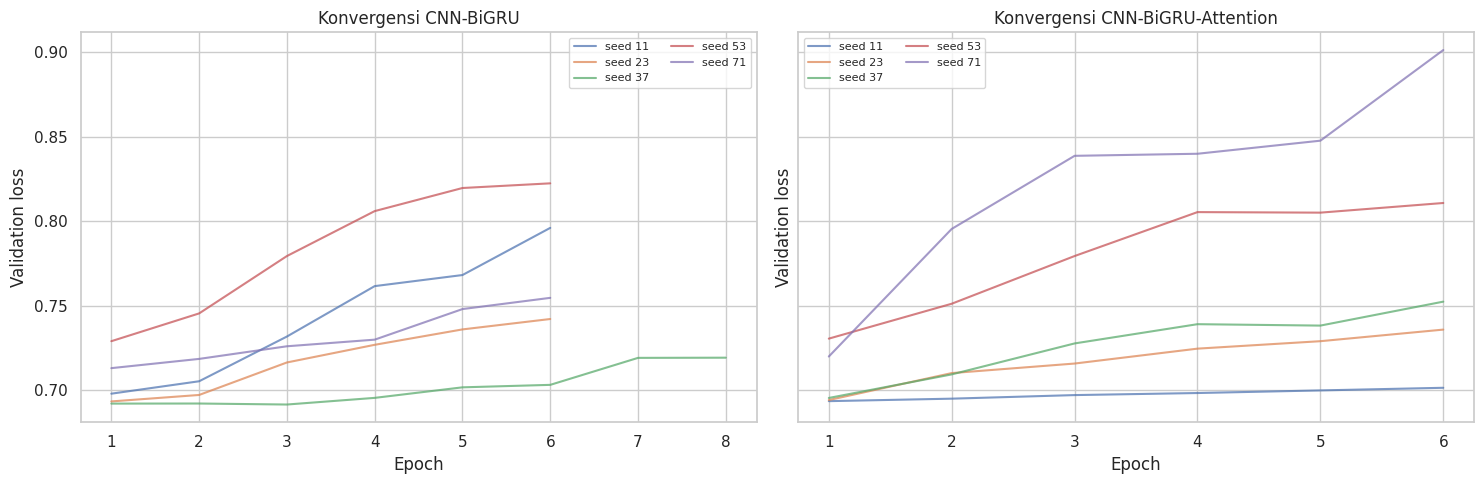

In [10]:
def auc(y,p): return roc_auc_score(y,p) if len(np.unique(y))==2 else np.nan
def get_attention(m,X):
    enc=tf.keras.Model(m.input,m.get_layer("bigru").output)
    h=enc.predict(X,verbose=0); layer=m.get_layer("attention")
    alpha=layer.compute_attention_weights(tf.convert_to_tensor(h))
    return tf.squeeze(alpha,-1).numpy()

def classification_metrics(y,prob,prefix):
    pred=(prob>=CFG["threshold"]).astype(int)
    return {f"{prefix}_Accuracy":accuracy_score(y,pred),
            f"{prefix}_Balanced_Accuracy":balanced_accuracy_score(y,pred),
            f"{prefix}_Precision":precision_score(y,pred,zero_division=0),
            f"{prefix}_Recall":recall_score(y,pred,zero_division=0),
            f"{prefix}_F1":f1_score(y,pred,zero_division=0),
            f"{prefix}_ROC_AUC":auc(y,prob)}

# Baseline dibangun hanya dari kelas mayoritas train. Validasi dan test tidak
# dipakai untuk menentukan kelas baseline.
majority_class=int(y_train.mean()>=.5)
train_prevalence=float(y_train.mean())
val_baseline_prob=np.full(len(y_val),train_prevalence,dtype=float)
val_baseline=classification_metrics(y_val,val_baseline_prob,"Val")
baseline_table=pd.DataFrame([{"Model":"Majority-class baseline",
  "Aturan":f"Selalu prediksi kelas {majority_class} berdasarkan train",
  "Train_Prevalence_Up":train_prevalence,**val_baseline}])
display(baseline_table.style.format({c:"{:.4f}" for c in baseline_table if c.startswith("Val_") or c=="Train_Prevalence_Up"}))

rows=[]; histories={}; trained_weights={"CNN-BiGRU":{},"CNN-BiGRU-Attention":{}}
val_predictions={"CNN-BiGRU":{},"CNN-BiGRU-Attention":{}}
attention_maps={}
for si,seed in enumerate(CFG["seeds"]):
    for use_att in ([False,True] if si%2==0 else [True,False]):
        label="CNN-BiGRU-Attention" if use_att else "CNN-BiGRU"
        gc.collect(); m=build_model(X_train.shape[1:],use_att,seed)
        cb=[tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=CFG["patience"],
              restore_best_weights=True,min_delta=1e-4),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=.5,
              patience=2,min_lr=1e-5)]
        t=time.perf_counter()
        h=m.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=CFG["epochs"],
                batch_size=CFG["batch_size"],shuffle=False,callbacks=cb,verbose=0)
        elapsed=time.perf_counter()-t
        val_prob=m.predict(X_val,verbose=0).ravel()
        val_predictions[label][seed]=val_prob
        trained_weights[label][seed]=[w.copy() for w in m.get_weights()]
        histories[(label,seed)]=h.history
        if use_att: attention_maps[seed]=get_attention(m,X_val[-min(200,len(X_val)):])
        row={"Model":label,"Seed":seed,"Train_Time_s":elapsed,
             "Parameters":m.count_params(),"Epochs_Run":len(h.history["loss"]),
             "Best_Val_Loss":min(h.history["val_loss"])}
        row.update(classification_metrics(y_val,val_prob,"Val"))
        rows.append(row)
        print(f"{label:24s} | seed={seed} | val_acc={row['Val_Accuracy']:.4f} | {elapsed:.1f}s")

results=pd.DataFrame(rows).sort_values(["Seed","Model"]).reset_index(drop=True)
metric_cols=[c for c in results if c.startswith("Val_")]
fmt={c:"{:.4f}" for c in metric_cols}
fmt.update({"Train_Time_s":"{:.1f}","Best_Val_Loss":"{:.4f}"})
display(results.style.format(fmt))

fig,ax=plt.subplots(1,2,figsize=(15,5),sharey=True)
for z,label,col in zip(ax,["CNN-BiGRU","CNN-BiGRU-Attention"],["#146C94","#D45087"]):
    for seed in CFG["seeds"]:
        curve=histories[(label,seed)]["val_loss"]
        z.plot(range(1,len(curve)+1),curve,alpha=.72,lw=1.5,label=f"seed {seed}")
    z.set(title=f"Konvergensi {label}",xlabel="Epoch",ylabel="Validation loss")
    z.legend(ncol=2,fontsize=8)
plt.tight_layout(); plt.show()

# Tahap 10. Stabilitas dan Interpretabilitas

Rubrik interpretabilitas 0 sampai 5 memadukan kesederhanaan (2), keterlacakan
waktu (1), dan reprodusibilitas prediksi antarseed (2). Rubrik ini transparan,
tetapi bukan bukti kausalitas atau standar industri.

,Model,Seed,Val_Accuracy,Val_Balanced_Accuracy,Val_Accuracy_Deviation,Train_Time_s,Interpretability_0_5
0,CNN-BiGRU,11,0.4574,0.498282,-0.0344,11.0,2.25
1,CNN-BiGRU-Attention,11,0.5426,0.500000,+0.0651,8.8,2.00
2,CNN-BiGRU,23,0.5426,0.500000,+0.0508,8.1,2.25
3,CNN-BiGRU-Attention,23,0.4758,0.474829,-0.0017,8.8,2.00
4,CNN-BiGRU,37,0.5442,0.505834,+0.0524,9.6,2.25
5,CNN-BiGRU-Attention,37,0.4541,0.465997,-0.0234,8.8,2.00
6,CNN-BiGRU,53,0.4574,0.500000,-0.0344,8.2,2.25
7,CNN-BiGRU-Attention,53,0.4574,0.500000,-0.0200,8.8,2.00
8,CNN-BiGRU,71,0.4574,0.500000,-0.0344,8.0,2.25
9,CNN-BiGRU-Attention,71,0.4574,0.500000,-0.0200,8.8,2.00


,Model,Val_Accuracy_Mean,Val_Accuracy_SD,Val_Accuracy_Min,Val_Accuracy_Max,Val_Balanced_Accuracy_Mean,Val_Balanced_Accuracy_SD,Val_F1_Mean,Val_F1_SD,Val_AUC_Mean,Train_Time_Mean_s,Train_Time_SD_s,Parameters,Prediction_Stability,Interpretability_0_5
0,CNN-BiGRU,0.4918,0.0471,0.4574,0.5442,0.5008,0.0029,0.2868,0.3768,0.5037,8.9950,1.3001,15969,-0.0767,2.2500
1,CNN-BiGRU-Attention,0.4775,0.0374,0.4541,0.5426,0.4882,0.0165,0.3197,0.3123,0.5010,8.7946,0.0308,18081,-0.0400,2.0000


,Model,Simplicity_0_2,Temporal_Trace_0_1,Reproducibility_0_2,Total_0_5
0,CNN-BiGRU,2.0,0.25,0.0,2.25
1,CNN-BiGRU-Attention,1.0,1.00,0.0,2.00


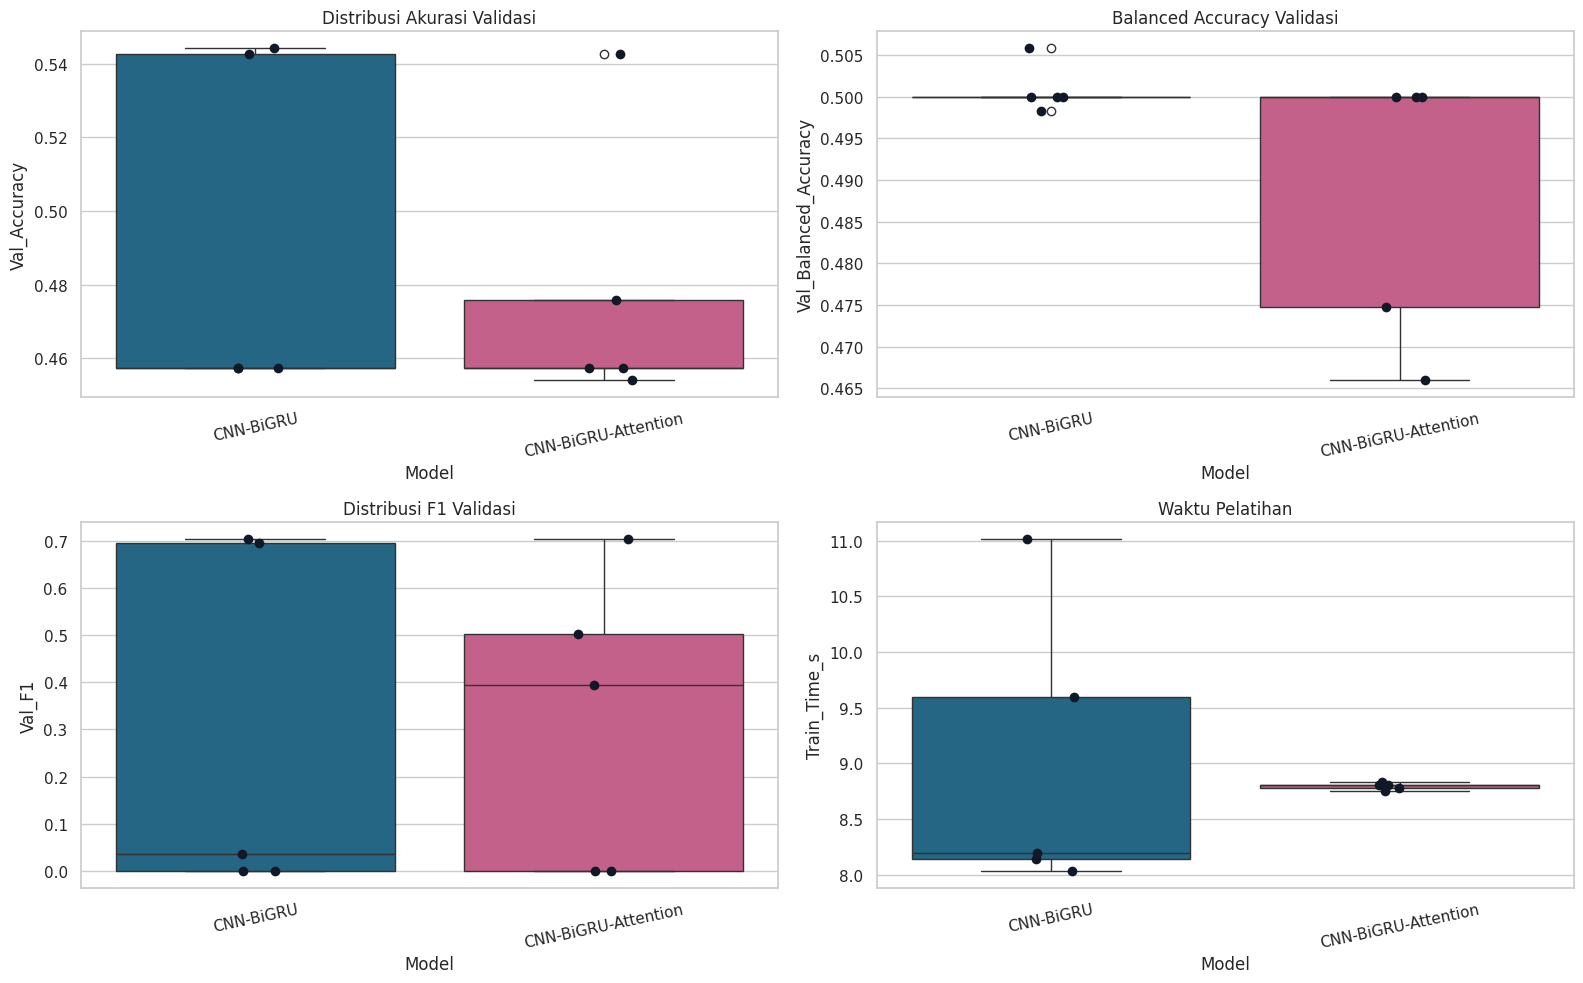

In [11]:
def stability(d):
    s=sorted(d); vals=[]
    for i in range(len(s)):
        for j in range(i+1,len(s)):
            q=spearmanr(d[s[i]],d[s[j]]).statistic
            if np.isfinite(q): vals.append(q)
    return float(np.mean(vals))

stab={k:stability(v) for k,v in val_predictions.items()}
rubric={"CNN-BiGRU":{"Simplicity_0_2":2.0,"Temporal_Trace_0_1":.25,
                     "Reproducibility_0_2":2*max(0,stab["CNN-BiGRU"])},
        "CNN-BiGRU-Attention":{"Simplicity_0_2":1.0,"Temporal_Trace_0_1":1.0,
                     "Reproducibility_0_2":2*max(0,stab["CNN-BiGRU-Attention"])}}
interp={k:float(np.clip(sum(v.values()),0,5)) for k,v in rubric.items()}
results["Prediction_Stability"]=results.Model.map(stab)
results["Interpretability_0_5"]=results.Model.map(interp)
results["Val_Accuracy_Deviation"]=results.Val_Accuracy-results.groupby("Model").Val_Accuracy.transform("mean")
summary=results.groupby("Model").agg(
 Val_Accuracy_Mean=("Val_Accuracy","mean"),Val_Accuracy_SD=("Val_Accuracy","std"),
 Val_Accuracy_Min=("Val_Accuracy","min"),Val_Accuracy_Max=("Val_Accuracy","max"),
 Val_Balanced_Accuracy_Mean=("Val_Balanced_Accuracy","mean"),
 Val_Balanced_Accuracy_SD=("Val_Balanced_Accuracy","std"),
 Val_F1_Mean=("Val_F1","mean"),Val_F1_SD=("Val_F1","std"),
 Val_AUC_Mean=("Val_ROC_AUC","mean"),
 Train_Time_Mean_s=("Train_Time_s","mean"),Train_Time_SD_s=("Train_Time_s","std"),
 Parameters=("Parameters","first"),Prediction_Stability=("Prediction_Stability","first"),
 Interpretability_0_5=("Interpretability_0_5","first")).reset_index()
rubric_df=pd.DataFrame(rubric).T.reset_index(names="Model")
rubric_df["Total_0_5"]=rubric_df.Model.map(interp)
display(results[["Model","Seed","Val_Accuracy","Val_Balanced_Accuracy","Val_Accuracy_Deviation","Train_Time_s",
 "Interpretability_0_5"]].style.format({"Val_Accuracy":"{:.4f}",
 "Val_Accuracy_Deviation":"{:+.4f}","Train_Time_s":"{:.1f}",
 "Interpretability_0_5":"{:.2f}"}))
display(summary.style.format({c:"{:.4f}" for c in summary if c not in ["Model","Parameters"]}))
display(rubric_df.round(3))

fig,ax=plt.subplots(2,2,figsize=(16,10))
ax=ax.ravel()
pal={"CNN-BiGRU":"#146C94","CNN-BiGRU-Attention":"#D45087"}
for z,metric,title in zip(ax,["Val_Accuracy","Val_Balanced_Accuracy","Val_F1","Train_Time_s"],
 ["Distribusi Akurasi Validasi","Balanced Accuracy Validasi","Distribusi F1 Validasi","Waktu Pelatihan"]):
    sns.boxplot(data=results,x="Model",y=metric,hue="Model",palette=pal,legend=False,ax=z)
    sns.stripplot(data=results,x="Model",y=metric,color="#111827",size=7,jitter=.08,ax=z)
    z.set_title(title); z.tick_params(axis="x",rotation=12)
plt.tight_layout(); plt.show()

# Tahap 11. Analisis Berpasangan dan *Attention*

Selisih memakai *seed* yang sama. Wilcoxon hanya menjadi informasi tambahan
karena lima pasangan memiliki daya statistik rendah. Bobot tinggi menunjukkan
fokus komputasional, bukan penyebab ekonomi.

,Seed,Val_Accuracy_Baseline,Val_Accuracy_Attention,Delta_Val_Accuracy,Val_Balanced_Accuracy_Baseline,Val_Balanced_Accuracy_Attention,Delta_Val_Balanced_Accuracy,Val_F1_Baseline,Val_F1_Attention,Delta_Val_F1,Val_ROC_AUC_Baseline,Val_ROC_AUC_Attention,Delta_Val_ROC_AUC,Train_Time_s_Baseline,Train_Time_s_Attention,Delta_Train_Time_s,Attention_Wins
0,11,0.4574,0.5426,0.0851,0.4983,0.5000,0.0017,0.0356,0.7035,0.6679,0.5131,0.4951,-0.0181,11.0159,8.8060,-2.2099,1.0000
1,23,0.5426,0.4758,-0.0668,0.5000,0.4748,-0.0252,0.7035,0.5016,-0.2019,0.4779,0.4935,0.0157,8.1369,8.7551,0.6182,0.0000
2,37,0.5442,0.4541,-0.0902,0.5058,0.4660,-0.0398,0.6950,0.3933,-0.3017,0.4862,0.4842,-0.0020,9.5996,8.8358,-0.7638,0.0000
3,53,0.4574,0.4574,0.0000,0.5000,0.5000,0.0000,0.0000,0.0000,0.0000,0.5280,0.5166,-0.0114,8.1926,8.8004,0.6078,0.0000
4,71,0.4574,0.4574,0.0000,0.5000,0.5000,0.0000,0.0000,0.0000,0.0000,0.5136,0.5158,0.0022,8.0301,8.7757,0.7456,0.0000


,Statistik,Nilai
0,Mean delta akurasi,-0.014357
1,Median delta,0.000000
2,Attention menang,1.000000
3,Wilcoxon statistic,2.000000
4,Wilcoxon p-value,0.750000
5,Sign-test p-value,1.000000
6,Bootstrap 95% CI bawah,-0.067446
7,Bootstrap 95% CI atas,0.037730


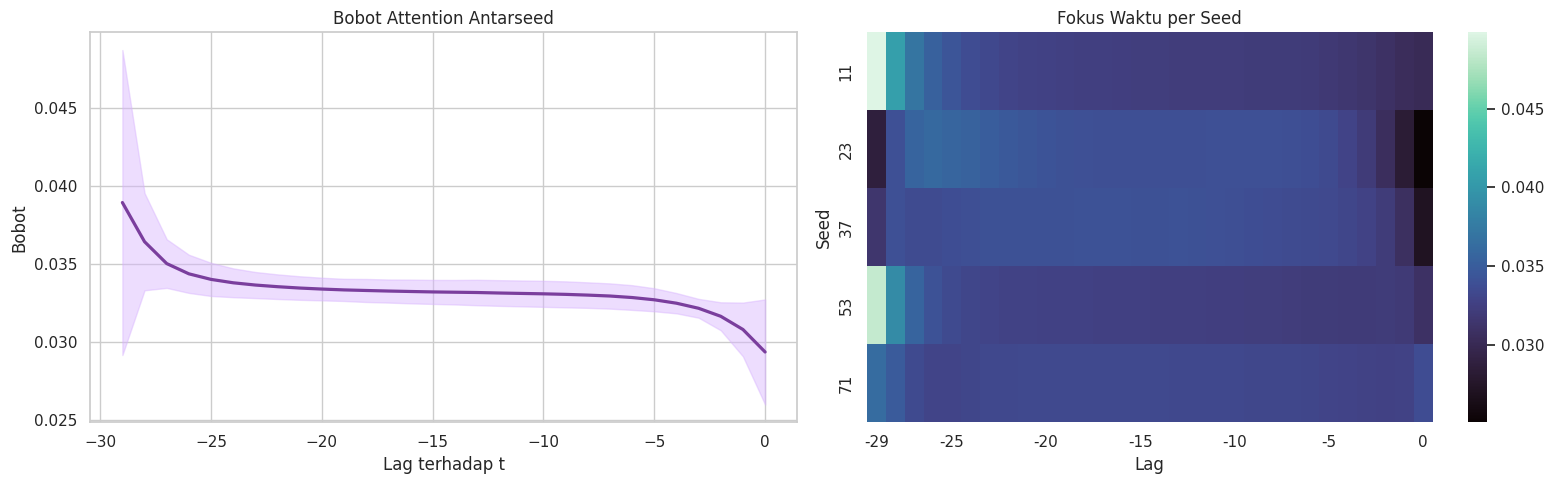

In [12]:
piv=results.pivot(index="Seed",columns="Model",values=["Val_Accuracy","Val_Balanced_Accuracy","Val_F1","Val_ROC_AUC","Train_Time_s"])
paired=pd.DataFrame(index=CFG["seeds"])
for mtr in ["Val_Accuracy","Val_Balanced_Accuracy","Val_F1","Val_ROC_AUC","Train_Time_s"]:
    paired[f"{mtr}_Baseline"]=piv[(mtr,"CNN-BiGRU")]
    paired[f"{mtr}_Attention"]=piv[(mtr,"CNN-BiGRU-Attention")]
    paired[f"Delta_{mtr}"]=paired[f"{mtr}_Attention"]-paired[f"{mtr}_Baseline"]
paired.index.name="Seed"; paired=paired.reset_index()
paired["Attention_Wins"]=paired.Delta_Val_Accuracy>0
try: W,P=wilcoxon(paired.Delta_Val_Accuracy)
except Exception: W,P=np.nan,np.nan
non_ties=paired.Delta_Val_Accuracy.ne(0)
sign_p=binomtest(int((paired.loc[non_ties,"Delta_Val_Accuracy"]>0).sum()),
                   int(non_ties.sum()),.5,alternative="two-sided").pvalue if non_ties.any() else 1.0
rng=np.random.default_rng(20260801)
delta=paired.Delta_Val_Accuracy.to_numpy()
boot=delta[rng.integers(0,len(delta),size=(CFG["bootstrap_repeats"],len(delta)))].mean(axis=1)
boot_low,boot_high=np.quantile(boot,[.025,.975])
display(paired.style.format({c:"{:.4f}" for c in paired if c!="Seed"}))
display(pd.DataFrame({"Statistik":["Mean delta akurasi","Median delta","Attention menang",
 "Wilcoxon statistic","Wilcoxon p-value","Sign-test p-value",
 "Bootstrap 95% CI bawah","Bootstrap 95% CI atas"],
 "Nilai":[paired.Delta_Val_Accuracy.mean(),paired.Delta_Val_Accuracy.median(),
          paired.Attention_Wins.sum(),W,P,sign_p,boot_low,boot_high]}))

stack=np.stack([attention_maps[s] for s in sorted(attention_maps)])
by_seed=stack.mean(axis=1); mean_att=by_seed.mean(axis=0); sd_att=by_seed.std(axis=0,ddof=1)
lags=np.arange(-CFG["window"]+1,1)
attention_summary=pd.DataFrame({"Lag":lags,"Attention_Mean":mean_att,"Attention_SD":sd_att})
fig,ax=plt.subplots(1,2,figsize=(16,5))
ax[0].plot(lags,mean_att,color="#7A3E9D",lw=2.3)
ax[0].fill_between(lags,mean_att-sd_att,mean_att+sd_att,color="#D8B4FE",alpha=.45)
ax[0].set(title="Bobot Attention Antarseed",xlabel="Lag terhadap t",ylabel="Bobot")
sns.heatmap(by_seed,cmap="mako",ax=ax[1],yticklabels=sorted(attention_maps),
 xticklabels=[str(x) if x%5==0 or x==-29 else "" for x in lags])
ax[1].set(title="Fokus Waktu per Seed",xlabel="Lag",ylabel="Seed")
plt.tight_layout(); plt.show()

# Tahap 12. Keputusan Arsitektur

Kriteria keputusan memisahkan manfaat prediktif dari pengaman stabilitas,
efisiensi, dan interpretabilitas. Rasio SD di bawah 1 berarti *Attention* lebih
stabil daripada pembanding. Uji statistik tetap diagnostik karena lima pasangan
belum memberi daya yang kuat untuk klaim universal.

In [13]:
S=summary.set_index("Model"); base=S.loc["CNN-BiGRU"]; att=S.loc["CNN-BiGRU-Attention"]
gain=att.Val_Accuracy_Mean-base.Val_Accuracy_Mean
gain_bal=att.Val_Balanced_Accuracy_Mean-base.Val_Balanced_Accuracy_Mean
wins=int(paired.Attention_Wins.sum())
sd_ratio=att.Val_Accuracy_SD/base.Val_Accuracy_SD if base.Val_Accuracy_SD>0 else (
 1.0 if att.Val_Accuracy_SD==0 else np.inf)
time_ratio=att.Train_Time_Mean_s/base.Train_Time_Mean_s
rules=pd.DataFrame([
 ["Manfaat prediktif","Kenaikan mean akurasi",gain,f">= {CFG['min_gain']:.3f}",gain>=CFG["min_gain"],True],
 ["Manfaat prediktif","Kenaikan balanced accuracy",gain_bal,f">= {CFG['min_gain']:.3f}",gain_bal>=CFG["min_gain"],True],
 ["Konsistensi","Kemenangan seed",wins,f">= {CFG['min_wins']}",wins>=CFG["min_wins"],True],
 ["Stabilitas","Rasio SD akurasi",sd_ratio,f"<= {CFG['max_sd_ratio']:.2f}",sd_ratio<=CFG["max_sd_ratio"],True],
 ["Efisiensi","Rasio waktu",time_ratio,f"<= {CFG['max_time_ratio']:.2f}",time_ratio<=CFG["max_time_ratio"],True],
 ["Interpretabilitas","Skor interpretabilitas",att.Interpretability_0_5,f">= {base.Interpretability_0_5:.2f}",
  att.Interpretability_0_5>=base.Interpretability_0_5,True],
 ["Inferensi diagnostik","Bootstrap CI seluruhnya positif",boot_low,f"> 0; CI=[{boot_low:+.4f}, {boot_high:+.4f}]",boot_low>0,False]],
 columns=["Dimensi","Kriteria","Nilai","Ambang","Lulus","Dipakai_untuk_keputusan"])
keep=bool(rules.loc[rules.Dipakai_untuk_keputusan,"Lulus"].all())
decision="PERTAHANKAN ATTENTION" if keep else "HAPUS ATTENTION DARI ARSITEKTUR AKHIR"
display(rules.style.apply(lambda r:["background-color:#DCFCE7" if r.Lulus else
 "#FEE2E2"]*len(r),axis=1))
failed=", ".join(rules.loc[rules.Dipakai_untuk_keputusan & ~rules.Lulus,"Kriteria"]) or "tidak ada"
sd_read=("lebih rendah, sehingga Attention lebih stabil" if sd_ratio<1 else
         "lebih tinggi, sehingga Attention kurang stabil" if sd_ratio>1 else "sama")
time_read=("lebih cepat" if time_ratio<1 else "lebih lambat" if time_ratio>1 else "setara")
ci_read=("mencakup nol, sehingga arah efek belum pasti" if boot_low<=0<=boot_high else
         "seluruhnya positif" if boot_low>0 else "seluruhnya negatif")
selected_val=att if keep else base
baseline_acc=float(val_baseline["Val_Accuracy"])
beats_majority=(selected_val.Val_Accuracy_Mean>baseline_acc and
                selected_val.Val_Balanced_Accuracy_Mean>.5)
viability=("MELAMPAUI BASELINE" if beats_majority else
           "BELUM TERBUKTI MELAMPAUI BASELINE")
memo=f'''
## Memorandum Keputusan

**Keputusan: {decision}.**

Pada validasi, CNN-BiGRU menghasilkan akurasi **{base.Val_Accuracy_Mean:.4f} ±
{base.Val_Accuracy_SD:.4f}**. CNN-BiGRU-*Attention* menghasilkan **{att.Val_Accuracy_Mean:.4f}
± {att.Val_Accuracy_SD:.4f}**. Selisih rata-rata yang dihitung langsung ialah
**{gain:+.4f}** atau **{gain*100:+.2f} poin persentase**. Selisih *balanced
accuracy* ialah **{gain_bal:+.4f}**. *Attention*
menang pada **{wins}/5 seed**. Rasio simpangan baku mencapai **{sd_ratio:.2f}**
dan nilainya {sd_read}. Rasio waktu pelatihan mencapai **{time_ratio:.2f}**,
sehingga model *Attention* {time_read} pada eksperimen ini. Skor
interpretabilitas pembanding ialah **{base.Interpretability_0_5:.2f}/5** dan
model *Attention* **{att.Interpretability_0_5:.2f}/5**.

Kriteria keputusan yang belum terpenuhi: {failed}. Interval *bootstrap* 95%
untuk selisih akurasi ialah **[{boot_low:+.4f}, {boot_high:+.4f}]** dan {ci_read}.
Wilcoxon p = **{P:.4f}** serta *sign test* p = **{sign_p:.4f}** hanya dibaca
sebagai diagnostik karena sampel terdiri dari lima pasangan *seed*.

Status terhadap *majority-class baseline*: **{viability}**. Akurasi baseline
validasi ialah **{baseline_acc:.4f}**, sedangkan *balanced accuracy* model
terpilih ialah **{selected_val.Val_Balanced_Accuracy_Mean:.4f}**. Pemilihan
arsitektur tidak otomatis membuktikan bahwa model layak untuk prediksi pasar.
Keputusan tidak memakai akurasi tertinggi dari satu putaran. Eksperimen lanjutan dapat menguji regularisasi,
unit atensi yang lebih kecil, panjang jendela, *learning rate*, dan jumlah
*seed* lebih besar tanpa mengubah periode uji atau aturan audit.
'''
display(Markdown(memo))

ValueError: Styles supplied as string must follow CSS rule formats, for example 'attr: val;'. '#FEE2E2' was given.


## Memorandum Keputusan

**Keputusan: HAPUS ATTENTION DARI ARSITEKTUR AKHIR.**

Pada validasi, CNN-BiGRU menghasilkan akurasi **0.4918 ±
0.0471**. CNN-BiGRU-*Attention* menghasilkan **0.4775
± 0.0374**. Selisih rata-rata yang dihitung langsung ialah
**-0.0144** atau **-1.44 poin persentase**. Selisih *balanced
accuracy* ialah **-0.0127**. *Attention*
menang pada **1/5 seed**. Rasio simpangan baku mencapai **0.79**
dan nilainya lebih rendah, sehingga Attention lebih stabil. Rasio waktu pelatihan mencapai **0.98**,
sehingga model *Attention* lebih cepat pada eksperimen ini. Skor
interpretabilitas pembanding ialah **2.25/5** dan
model *Attention* **2.00/5**.

Kriteria keputusan yang belum terpenuhi: Kenaikan mean akurasi, Kenaikan balanced accuracy, Kemenangan seed, Skor interpretabilitas. Interval *bootstrap* 95%
untuk selisih akurasi ialah **[-0.0674, +0.0377]** dan mencakup nol, sehingga arah efek belum pasti.
Wilcoxon p = **0.7500** serta *sign test* p = **1.0000** hanya dibaca
sebagai diagnostik karena sampel terdiri dari lima pasangan *seed*.

Status terhadap *majority-class baseline*: **BELUM TERBUKTI MELAMPAUI BASELINE**. Akurasi baseline
validasi ialah **0.5426**, sedangkan *balanced accuracy* model
terpilih ialah **0.5008**. Pemilihan
arsitektur tidak otomatis membuktikan bahwa model layak untuk prediksi pasar.
Keputusan tidak memakai akurasi tertinggi dari satu putaran. Eksperimen lanjutan dapat menguji regularisasi,
unit atensi yang lebih kecil, panjang jendela, *learning rate*, dan jumlah
*seed* lebih besar tanpa mengubah periode uji atau aturan audit.


# Tahap 13. Konfirmasi pada Data Uji
Metrik uji dihitung setelah arsitektur dipilih dari validasi. Probabilitas lima
*seed* dirata-ratakan untuk memperoleh estimasi akhir yang lebih stabil.

2026-07-31 21:48:40.386461: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,Model,Seed,Test_Accuracy,Test_Balanced_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,CNN-BiGRU,11,0.4791,0.5000,0.0000,0.0000,0.0000,0.5244
1,CNN-BiGRU,23,0.5209,0.5000,0.5209,1.0000,0.6850,0.5113
2,CNN-BiGRU,37,0.5209,0.5004,0.5211,0.9904,0.6829,0.5277
3,CNN-BiGRU,53,0.4825,0.5031,0.7500,0.0096,0.0190,0.5313
4,CNN-BiGRU,71,0.5025,0.5201,0.6458,0.0994,0.1722,0.5073


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,CNN-BiGRU,0.5142,0.5260,0.5802,0.2436,0.3431,0.5550


,Model,Accuracy,Balanced_Accuracy,F1,ROC_AUC
0,CNN-BiGRU,0.5142,0.5260,0.3431,0.5550
1,Majority-class baseline,0.5209,0.5000,0.6850,0.5000


,Prediksi Turun/Tetap,Prediksi Naik
Aktual Turun/Tetap,232,55
Aktual Naik,236,76


,precision,recall,f1-score,support
Turun/Tetap,0.4957,0.8084,0.6146,287.0000
Naik,0.5802,0.2436,0.3431,312.0000
accuracy,0.5142,0.5142,0.5142,0.5142
macro avg,0.5379,0.5260,0.4788,599.0000
weighted avg,0.5397,0.5142,0.4732,599.0000


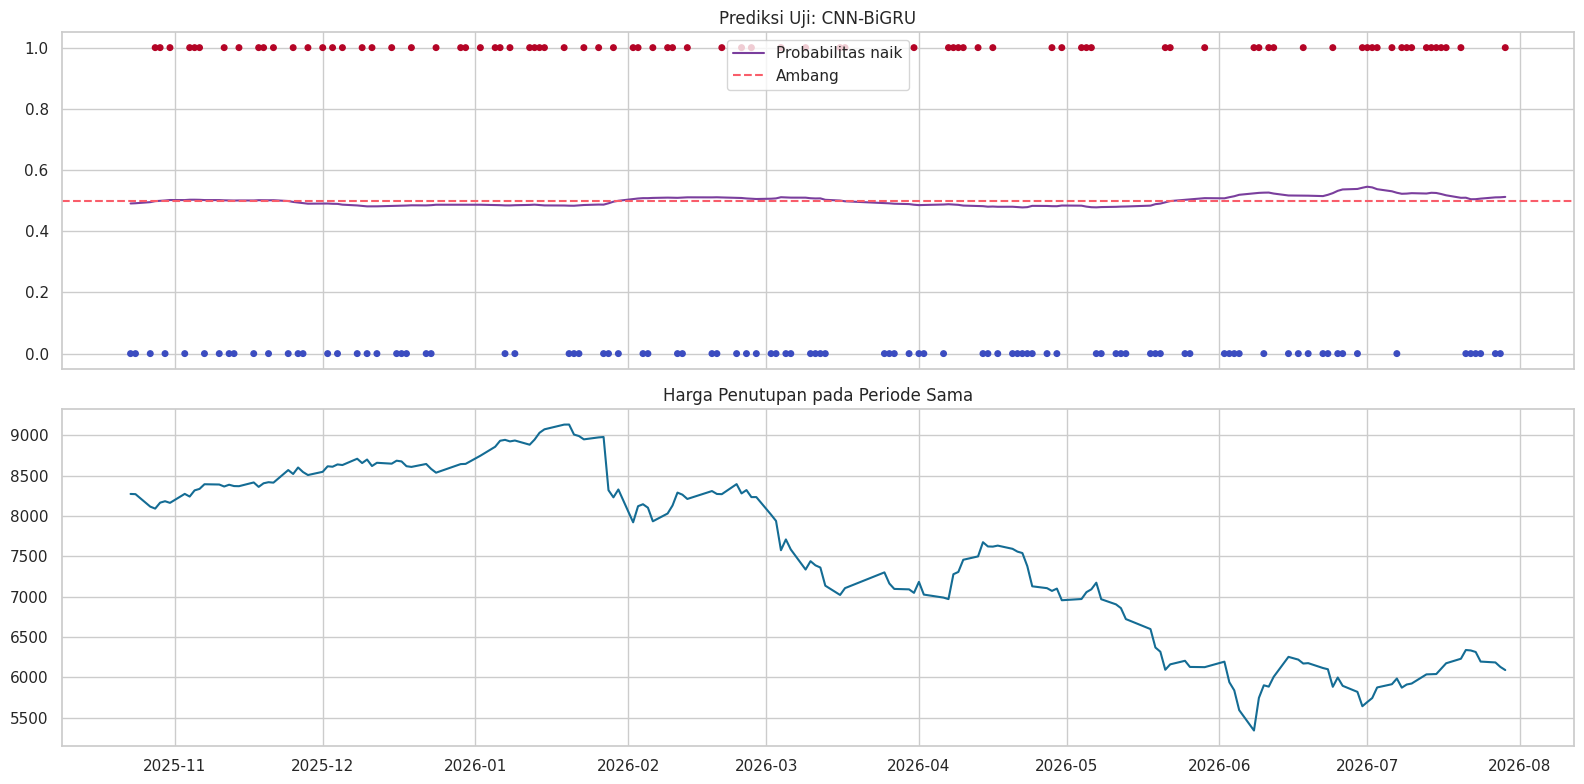

In [14]:
selected="CNN-BiGRU-Attention" if keep else "CNN-BiGRU"
selected_uses_attention=selected=="CNN-BiGRU-Attention"
test_predictions={}; test_seed_rows=[]
for seed in CFG["seeds"]:
    confirm=build_model(X_train.shape[1:],selected_uses_attention,seed)
    confirm.set_weights(trained_weights[selected][seed])
    seed_prob=confirm.predict(X_test,verbose=0).ravel()
    test_predictions[seed]=seed_prob
    seed_row={"Model":selected,"Seed":seed}
    seed_row.update(classification_metrics(y_test,seed_prob,"Test"))
    test_seed_rows.append(seed_row)
test_by_seed=pd.DataFrame(test_seed_rows)
display(test_by_seed.style.format({c:"{:.4f}" for c in test_by_seed if c.startswith("Test_")}))
prob=np.mean(np.stack([test_predictions[s] for s in CFG["seeds"]]),axis=0)
pred=(prob>=CFG["threshold"]).astype(int)
cm=confusion_matrix(y_test.astype(int),pred)
final_test=pd.DataFrame({"Model":[selected],"Accuracy":[accuracy_score(y_test,pred)],
 "Balanced_Accuracy":[balanced_accuracy_score(y_test,pred)],
 "Precision":[precision_score(y_test,pred,zero_division=0)],
 "Recall":[recall_score(y_test,pred,zero_division=0)],
 "F1":[f1_score(y_test,pred,zero_division=0)],"ROC_AUC":[auc(y_test,prob)]})
display(final_test.style.format({c:"{:.4f}" for c in final_test if c!="Model"}))
test_baseline_prob=np.full(len(y_test),train_prevalence,dtype=float)
test_baseline_metrics=classification_metrics(y_test,test_baseline_prob,"Test")
test_comparison=pd.DataFrame([
 {"Model":selected,"Accuracy":final_test.Accuracy.iloc[0],
  "Balanced_Accuracy":final_test.Balanced_Accuracy.iloc[0],
  "F1":final_test.F1.iloc[0],"ROC_AUC":final_test.ROC_AUC.iloc[0]},
 {"Model":"Majority-class baseline","Accuracy":test_baseline_metrics["Test_Accuracy"],
  "Balanced_Accuracy":test_baseline_metrics["Test_Balanced_Accuracy"],
  "F1":test_baseline_metrics["Test_F1"],"ROC_AUC":test_baseline_metrics["Test_ROC_AUC"]}])
display(test_comparison.style.format({c:"{:.4f}" for c in test_comparison if c!="Model"}))
display(pd.DataFrame(cm,index=["Aktual Turun/Tetap","Aktual Naik"],
 columns=["Prediksi Turun/Tetap","Prediksi Naik"]))
display(pd.DataFrame(classification_report(y_test.astype(int),pred,
 target_names=["Turun/Tetap","Naik"],output_dict=True,zero_division=0)).T.round(4))
nplot=min(180,len(y_test)); fig,ax=plt.subplots(2,1,figsize=(16,8),sharex=True)
ax[0].plot(d_test[-nplot:],prob[-nplot:],color="#7A3E9D",label="Probabilitas naik")
ax[0].axhline(.5,color="#F95D6A",ls="--",label="Ambang")
ax[0].scatter(d_test[-nplot:],y_test[-nplot:],c=y_test[-nplot:],cmap="coolwarm",s=16)
ax[0].set_title(f"Prediksi Uji: {selected}"); ax[0].legend()
ax[1].plot(d_test[-nplot:],data.loc[d_test[-nplot:],"Close"],color="#146C94")
ax[1].set_title("Harga Penutupan pada Periode Sama"); plt.tight_layout(); plt.show()

# Tahap 14. Register Bug dan Mitigasi
Risiko teknis dan metodologis dicatat secara terbuka.

In [15]:
errors=pd.DataFrame([
 ["Internet mati","Akuisisi","Proses berhenti","Fallback CSV Kaggle","TERMITIGASI"],
 ["Kolom MultiIndex","Akuisisi","KeyError OHLCV","Perataan nama kolom","TERMITIGASI"],
 ["Target akhir palsu","Target","Label salah","Target NaN bila t+1 tidak ada","TERMITIGASI"],
 ["Scaler memakai test","Normalisasi","Leakage","Fit train-only","TERMITIGASI"],
 ["Split acak","Split","Masa depan masuk train","Split kronologis","TERMITIGASI"],
 ["Tensor bukan 3D","Model","GRU salah","Audit shape [N,30,F]","TERMITIGASI"],
 ["Metode bernama weights","Keras 3","count_params gagal","Gunakan compute_attention_weights","TERMITIGASI"],
 ["Satu seed tinggi","Evaluasi","Klaim berlebihan","Mean, SD, lima seed","TERMITIGASI"],
 ["Akurasi tanpa baseline","Evaluasi","Model lemah tampak baik","Majority baseline dan balanced accuracy","TERMITIGASI"],
 ["Rasio SD disalahartikan","Evaluasi","Kesimpulan stabilitas terbalik","Rasio < 1 berarti variasi Attention lebih rendah","TERMITIGASI"],
 ["Lima seed dianggap konklusif","Inferensi","Daya uji terlalu rendah","Wilcoxon, sign test, bootstrap sebagai diagnostik","DIPANTAU"],
 ["Test dipakai memilih model","Evaluasi","Bias seleksi","Keputusan hanya dari validasi","TERMITIGASI"],
 ["Test satu kelas","Evaluasi","AUC gagal","Audit kelas dan safe AUC","DIPANTAU"],
 ["Bobot dianggap sebab","Interpretasi","Klaim ekonomi salah","Label nonkausal","DIPANTAU"],
 ["Concept drift","Generalisasi","Kinerja masa depan turun","Walk-forward lanjutan","BELUM DIUJI"]],
 columns=["Masalah","Tahap","Dampak","Mitigasi","Status"])
display(errors.style.apply(lambda r:["background-color:#DCFCE7" if r.Status=="TERMITIGASI"
 else "background-color:#FEF3C7"]*len(r),axis=1))

,Masalah,Tahap,Dampak,Mitigasi,Status
0,Internet mati,Akuisisi,Proses berhenti,Fallback CSV Kaggle,TERMITIGASI
1,Kolom MultiIndex,Akuisisi,KeyError OHLCV,Perataan nama kolom,TERMITIGASI
2,Target akhir palsu,Target,Label salah,Target NaN bila t+1 tidak ada,TERMITIGASI
3,Scaler memakai test,Normalisasi,Leakage,Fit train-only,TERMITIGASI
4,Split acak,Split,Masa depan masuk train,Split kronologis,TERMITIGASI
5,Tensor bukan 3D,Model,GRU salah,"Audit shape [N,30,F]",TERMITIGASI
6,Metode bernama weights,Keras 3,count_params gagal,Gunakan compute_attention_weights,TERMITIGASI
7,Satu seed tinggi,Evaluasi,Klaim berlebihan,"Mean, SD, lima seed",TERMITIGASI
8,Akurasi tanpa baseline,Evaluasi,Model lemah tampak baik,Majority baseline dan balanced accuracy,TERMITIGASI
9,Rasio SD disalahartikan,Evaluasi,Kesimpulan stabilitas terbalik,Rasio < 1 berarti variasi Attention lebih rendah,TERMITIGASI


# Tahap 15. Integritas dan Ekspor

**VALID** berarti audit kritis lulus. **MERAGUKAN** berarti audit lulus, tetapi
kelas, ukuran uji, variasi, atau kegagalan melampaui baseline membatasi kesimpulan. **TIDAK SAH** berarti
terdapat kegagalan audit kritis.

In [16]:
critical_ok=audit_df.query("Tingkat=='KRITIS'").Lulus.all()
high_ok=audit_df.query("Tingkat=='TINGGI'").Lulus.all()
size_ok=len(X_test)>=200; variation=max(base.Val_Accuracy_SD,att.Val_Accuracy_SD)<=.05
status="TIDAK SAH" if not critical_ok else (
 "MERAGUKAN" if not(high_ok and size_ok and variation and beats_majority) else "VALID")
integrity=pd.DataFrame({"Komponen":["Audit kritis","Validasi dan test dua kelas","Test >= 200",
 "SD <= 0,05","Melampaui baseline validasi","Status","Keputusan"],
 "Hasil":[bool(critical_ok),bool(high_ok),bool(size_ok),bool(variation),bool(beats_majority),status,decision]})
display(integrity)

data.reset_index().to_csv(OUT/"01_ihsg_processed.csv",index=False)
audit_df.to_csv(OUT/"02_data_leakage_audit.csv",index=False)
results.to_csv(OUT/"03_five_seed_results.csv",index=False)
summary.to_csv(OUT/"04_model_summary.csv",index=False)
paired.to_csv(OUT/"05_paired_seed_deltas.csv",index=False)
attention_summary.to_csv(OUT/"06_attention_by_lag.csv",index=False)
rules.to_csv(OUT/"07_decision_rules.csv",index=False)
errors.to_csv(OUT/"08_error_bug_register.csv",index=False)
rubric_df.to_csv(OUT/"09_interpretability_rubric.csv",index=False)
test_by_seed.to_csv(OUT/"10_final_test_by_seed.csv",index=False)
final_test.to_csv(OUT/"11_final_test_ensemble.csv",index=False)
baseline_table.to_csv(OUT/"12_validation_majority_baseline.csv",index=False)
test_comparison.to_csv(OUT/"13_test_model_vs_baseline.csv",index=False)
(OUT/"14_decision_memo.md").write_text(memo,encoding="utf-8")
(OUT/"00_config.json").write_text(json.dumps(CFG,indent=2,ensure_ascii=False),encoding="utf-8")
archive=shutil.make_archive("/kaggle/working/ihsg_attention_5seed_results","zip",root_dir=OUT)
files=sorted(OUT.iterdir())
display(pd.DataFrame({"File":[p.name for p in files],
                      "Ukuran_KB":[round(p.stat().st_size/1024,2) for p in files]}))
display(Markdown(f"## Status Akhir: **{status}**\\n**Keputusan:** {decision}\\n\\nArsip: `{archive}`"))

,Komponen,Hasil
0,Audit kritis,True
1,Validasi dan test dua kelas,True
2,Test >= 200,True
3,"SD <= 0,05",True
4,Melampaui baseline validasi,False
5,Status,MERAGUKAN
6,Keputusan,HAPUS ATTENTION DARI ARSITEKTUR AKHIR


,File,Ukuran_KB
0,00_config.json,0.38
1,01_ihsg_processed.csv,1278.46
2,02_data_leakage_audit.csv,0.51
3,03_five_seed_results.csv,2.09
4,04_model_summary.csv,0.75
5,05_paired_seed_deltas.csv,1.56
6,06_attention_by_lag.csv,0.87
7,07_decision_rules.csv,0.57
8,08_error_bug_register.csv,1.29
9,09_interpretability_rubric.csv,0.13


## Status Akhir: **MERAGUKAN**\n**Keputusan:** HAPUS ATTENTION DARI ARSITEKTUR AKHIR\n\nArsip: `/kaggle/working/ihsg_attention_5seed_results.zip`

# Analisis Kritis

Lima *seed* membentuk distribusi bukti awal. Nilai maksimum tunggal mudah
dipengaruhi inisialisasi dan lintasan optimasi. Rata-rata menggambarkan manfaat
tipikal, sedangkan simpangan baku mengukur variasi antarputaran. Rasio SD di
bawah 1 berarti variasi model *Attention* lebih kecil. Kondisi ini tidak boleh
ditulis sebagai ketidakstabilan. Selisih berpasangan menunjukkan apakah
*Attention* menang saat kondisi acak disamakan.

Akurasi juga harus dibandingkan dengan prediksi kelas mayoritas. *Balanced
accuracy* mencegah kelas dominan menutupi kegagalan mengenali kelas lain. Nilai
sekitar 0,50 pada metrik ini menunjukkan kinerja yang mendekati tebakan acak.
Pemilihan arsitektur terbaik di antara dua kandidat tidak otomatis membuktikan
bahwa kandidat terpilih berguna secara prediktif.

Biaya waktu dan parameter harus ikut dinilai. Peningkatan kecil tidak cukup
kuat jika variasinya besar atau waktu meningkat tajam. Bobot *Attention* juga
tidak membuktikan sebab ekonomi. Ia hanya menunjukkan posisi representasi yang
dipakai model.

Aturan akhir sengaja konservatif. Model tanpa *Attention* dipilih jika satu
kriteria utama gagal. Keputusan dapat diuji ulang melalui *walk-forward
validation*, regularisasi, optimasi hiperparameter pada validasi, dan jumlah
*seed* yang lebih besar. Wilcoxon, *sign test*, dan interval *bootstrap* pada
lima pasangan hanya berfungsi sebagai diagnostik. Data uji tidak ikut
menentukan arsitektur. Ia baru
dipakai sesudah keputusan untuk mengukur kemampuan generalisasi secara lebih
jujur. Audit waktu dan periode uji harus tetap sama.